# Automated Valuation Model (AVM) – Predykcja Cen Nieruchomości w Warszawie
### Zaawansowany silnik predykcyjny wspierający zarządzanie ryzykiem kredytowym

---

* **Autor:** Adam Andrzejczyk
* **Dziedzina:** Matematyka Stosowana & Financial Data Science
* **Charakter projektu:** Professional Case Study – Modelowanie Ryzyka i AVM
* **Data:** Kwiecień 2026

---

## 1. Wstęp, Cel i Ramy Projektu

Niniejszy projekt koncentruje się na budowie zaawansowanego modelu **AVM (Automated Valuation Model)**. Głównym celem jest dostarczenie precyzyjnego narzędzia analitycznego, które optymalizuje procesy automatycznej wyceny zabezpieczeń nieruchomości w sektorze bankowym. Narzędzie to ma kluczowe znaczenie dla instytucji finansowych w kontekście monitorowania wartości portfela oraz zarządzania kapitałem zgodnie z wymogami regulacyjnymi.

**Kluczowe parametry i etapy analizy:**

* **Zakres danych:** Rynek wtórny nieruchomości w Warszawie (okres: 08.2023 – 06.2024).
* **Metodologia:** Silnik oparty na algorytmie **XGBoost** z wykorzystaniem zaawansowanej inżynierii cech (**Geospatial Feature Engineering**) opartej na współrzędnych GPS.
* **Proces badawczy:**
    1. **Analiza Eksploracyjna (EDA):** Identyfikacja trendów rynkowych, korelacji zmiennych oraz struktur cenowych w ujęciu dzielnicowym.
    2. **Inżynieria i Przygotowanie Danych:** Czyszczenie zbioru, obsługa wartości odstających, transformacja zmiennych oraz ekstrakcja cech z danych lokalizacyjnych.
    3. **Modelowanie i Walidacja:** Trening modelu, tuning hiperparametrów oraz rygorystyczna ocena stabilności predykcji na zbiorze testowym.
    4. **Interpretacja Biznesowa:** Analiza determinantów ceny i ich przełożenie na parametry ryzyka (**LGD**) oraz zgodność ze standardem **IFRS 9** (szacowanie strat oczekiwanych – **ECL**).

### 1.1. Definicja Problemu Matematycznego

Celem jest konstrukcja estymatora regresyjnego, który wyznacza cenę nieruchomości jako funkcję jej cech fizycznych oraz precyzyjnych zmiennych lokalizacyjnych:

$$Price = f(Area, District, Construction\_Year, Location\_GPS, ...) + \epsilon$$

Gdzie $\epsilon$ reprezentuje błąd modelu, który minimalizujemy poprzez optymalizację nieliniowej funkcji celu algorytmu **XGBoost**.

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

## 2. Proces ETL: Agregacja i Normalizacja Danych

W tej sekcji przeprowadzamy proces **ETL (Extract, Transform, Load)**. Automatyzujemy wczytywanie rozproszonych plików snapshotów rynkowych, filtrujemy dane pod kątem lokalizacji (Warszawa) oraz ujednolicamy typy numeryczne. Kluczowym elementem jest ekstrakcja daty z nazw plików, co pozwoli modelowi **XGBoost** uwzględnić czynnik zmienności cen w czasie.

### 2.1. Selekcja Cech (Feature Selection) i Uzasadnienie Biznesowe

Wybór zmiennych objaśniających oparto na fundamentach ekonomicznych rynku nieruchomości oraz analizie korelacji. Wyselekcjonowane cechy podzielono na trzy grupy:

1. **Cechy Fizyczne (Internal):**
   * `squareMeters`: Główny determinant ceny (skalowalność powierzchni).
   * `rooms`: Informacja o układzie funkcjonalnym (istotna dla segmentu student/rodzina).
   * `floor`: Wpływ nieliniowy (parter i ostatnie piętro często mają inne wyceny).

2. **Cechy Lokalizacyjne (Geospatial):**
   * `latitude`, `longitude`: Kluczowe dla modelu XGBoost, który potrafi wyłapać nieliniowe "gorące punkty" na mapie Warszawy (np. bliskość metra czy parków).
   * `city`: Filtr stały dla zapewnienia homogeniczności zbioru (tylko rynek warszawski).

3. **Czynnik Czasowy (Temporal):**
   * `snapshot_date`: Pozwala modelowi odróżnić trendy rynkowe i uwzględnić dynamikę wzrostu cen (inflacja/popyt) w różnych miesiącach.

Świadomie odrzucono zmienne o niskiej wartości informacyjnej lub wysokim zaszumieniu (np. opisy tekstowe), aby zminimalizować ryzyko overfittingu.

### 2.2. Strategia obsługi braków danych (Data Cleaning)

Zastosowano metodę **Listwise Deletion** (`dropna`) dla kluczowych zmiennych objaśniających oraz zmiennej celu.

> **Uzasadnienie decyzji:**
> W analityce bankowej priorytetem jest **integralność danych** oraz wysoka jakość sygnału nad surową ilością rekordów. Rezygnacja ze sztucznej imputacji (np. średnią lub medianą) na rzecz usunięcia niekompletnych obserwacji minimalizuje ryzyko wprowadzenia **błędu systematycznego ($bias$)** do modelu. Dzięki temu algorytm uczy się wyłącznie na realnych i w pełni wiarygodnych informacjach rynkowych, co jest kluczowe z punktu widzenia późniejszego zarządzania ryzykiem.

In [2]:
# 2. Proces ETL: Agregacja, Ekstrakcja Danych i Normalizacja

path = "./"
all_files = glob.glob(os.path.join(path, "apartments_pl_*.csv"))

li = []

# Definiujemy kolumny kluczowe dla modelu
relevant_columns = [
    'city', 'price', 'squareMeters', 'rooms', 'floor',
    'latitude', 'longitude', 'type', 'condition', 'buildingMaterial'
]

print(f"Rozpoczynam wczytywanie {len(all_files)} plików...")

for filename in all_files:
    try:
        # Wczytujemy tylko zdefiniowane kolumny
        df_temp = pd.read_csv(filename, usecols=lambda x: x in relevant_columns)

        if not df_temp.empty:
            # Ekstrakcja daty z nazwy pliku 
            file_name_only = os.path.basename(filename)
            # Wyciągamy YYYY_MM 
            parts = file_name_only.replace('.csv', '').split('_')
            date_part = f"{parts[-2]}_{parts[-1]}" 
            
            df_temp['snapshot_date'] = date_part
            li.append(df_temp)

    except Exception as e:
        print(f"Błąd w pliku {filename}: {e}")

if li:
    # Łączenie wszystkich snapshotów w jeden DataFrame
    df = pd.concat(li, ignore_index=True)

    # --- KLUCZOWY FIX: Filtracja terytorialna ---
    # Upewniamy się, że model uczy się tylko na danych z Warszawy
    df = df[df['city'].str.lower() == 'warszawa'].copy()

    # Konwersja typów danych na numeryczne
    cols_to_fix = ['price', 'squareMeters', 'rooms', 'floor', 'latitude', 'longitude']
    for col in cols_to_fix:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # CZYSZCZENIE: Usuwamy rekordy niekompletne w kluczowych zmiennych
    # Wybieramy 'listwise deletion' dla zapewnienia najwyższej jakości sygnał
    essential_cols = ['price', 'squareMeters', 'type', 'condition']
    df.dropna(subset=essential_cols, inplace=True)

    # Wyliczenie ceny za m2 (zmienna bazowa dla analityki i detekcji outlierów)
    df['price_per_m2'] = df['price'] / df['squareMeters']

    print("-" * 30)
    print(f"SUKCES! Proces ETL zakończony pomyślnie.")
    print(f"Zbiór wynikowy: {len(df)} ofert z Warszawy.")
    print(f"Analizowane okresy: {sorted(df['snapshot_date'].unique())}")
    print("-" * 30)
else:
    print(f"BŁĄD: Nie udało się wczytać danych. Sprawdź ścieżkę: {path}")

# Podgląd zbioru po filtracji na Warszawę
df.head()

Rozpoczynam wczytywanie 11 plików...
------------------------------
SUKCES! Proces ETL zakończony pomyślnie.
Zbiór wynikowy: 12321 ofert z Warszawy.
Analizowane okresy: ['2023_08', '2023_09', '2023_10', '2023_11', '2023_12', '2024_01', '2024_02', '2024_03', '2024_04', '2024_05', '2024_06']
------------------------------


,city,type,squareMeters,rooms,floor,latitude,longitude,buildingMaterial,condition,price,snapshot_date,price_per_m2
12493,warszawa,apartmentBuilding,112.80,4.0,2.0,52.236141,20.987732,brick,premium,2050000,2023_08,18173.758865
12495,warszawa,blockOfFlats,60.00,3.0,NaN,52.260800,21.058970,NaN,premium,700000,2023_08,11666.666667
12503,warszawa,tenement,50.00,2.0,1.0,52.193716,21.003591,brick,premium,975000,2023_08,19500.000000
12504,warszawa,apartmentBuilding,63.78,3.0,5.0,52.195434,20.905345,brick,premium,937566,2023_08,14700.000000
12509,warszawa,blockOfFlats,53.40,3.0,2.0,52.239178,20.948655,NaN,low,775000,2023_08,14513.108614


# 3. Eksploracyjna Analiza Danych (EDA) i Sanity Check

Zanim przystąpimy do modelowania, musimy zagwarantować wysoką jakość zbioru uczącego (**Data Integrity**). W bankowości kluczowe jest, aby algorytm nie uczył się na „szumie” (anomaliach rynkowych), co mogłoby prowadzić do błędnej wyceny ryzyka kredytowego.

### 3.1. Detekcja Outlierów metodą Tukey's Fences

**Opis kroku:**
Zastosowano algorytm identyfikacji wartości odstających oparty na rozstępie ćwiartkowym ($IQR$). Za granice "typowe" dla ceny za metr kwadratowy uznano wartości mieszczące się w przedziale:
$$[Q1 - 1.5 \cdot IQR, \ Q3 + 1.5 \cdot IQR]$$

> **Uzasadnienie decyzji:**
> * **Odporność (Robustness):** Wybrano metodę $IQR$ zamiast Z-score ze względu na silną **prawostronną skośność** rozkładu cen mieszkań. Średnia arytmetyczna (baza Z-score) jest zbyt wrażliwa na ekstremalnie drogie apartamenty, co mogłoby skutkować nierealistycznymi granicami odcięcia. $IQR$ opiera się na medianie, co czyni proces czyszczenia odpornym na pojedyncze anomalie.
> * **Wiedza domenowa (Domain Knowledge):** Nałożono dodatkowe filtry na metraż ($15 - 250 \ m^2$). Pozwala to wykluczyć lokale użytkowe (mikrokawalerki) oraz rezydencje luksusowe, które stanowią osobne segmenty rynku i wymagałyby oddzielnej specyfikacji modelu.

### 3.2. Wyniki filtracji i analiza rozkładu (KDE)

Po wykonaniu poniższego kodu, uzyskujemy zweryfikowany zbiór `df_clean`, gotowy do procesu uczenia maszynowego. Wykres **KDE (Kernel Density Estimation)** pozwala na wizualną ocenę sukcesu filtracji.

Statystyka czyszczenia:
- Granica dolna ceny/m2: 5489.02 PLN
- Granica górna ceny/m2: 28885.13 PLN
- Usunięto 148 rekordów (1.2% danych).


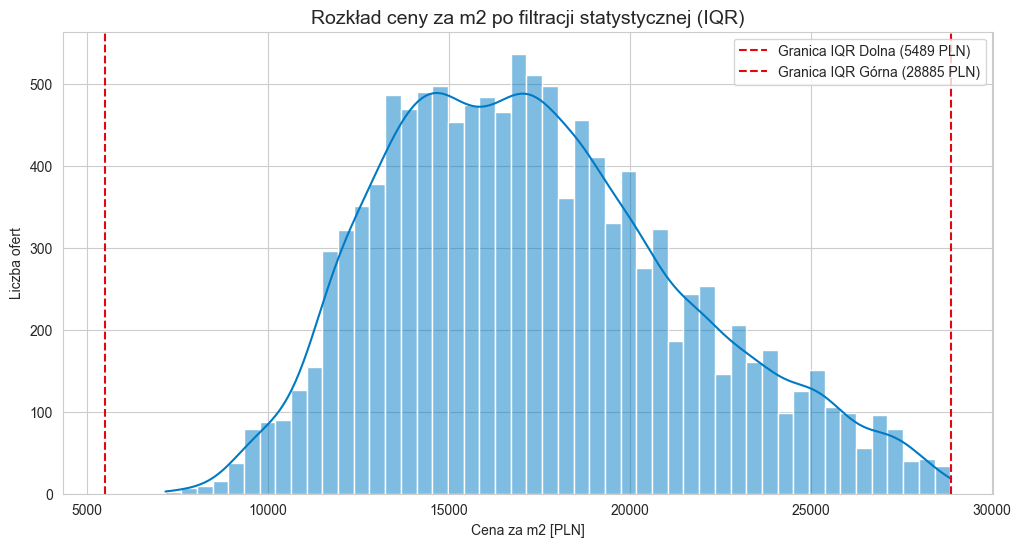

In [3]:
# 3. Zaawansowane Czyszczenie i Detekcja Outlierów
# Obliczamy kwartyle dla ceny za m2 (najbardziej miarodajna cecha do czyszczenia)
Q1 = df['price_per_m2'].quantile(0.25)
Q3 = df['price_per_m2'].quantile(0.75)
IQR = Q3 - Q1

# Definiujemy granice statystyczne (Metoda Tukey'a)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Nakładamy filtry 
# Usuwamy rekordy poza "płotkami" IQR oraz skrajne metraże
df_clean = df[
    (df['price_per_m2'] >= lower_bound) &
    (df['price_per_m2'] <= upper_bound) &
    (df['squareMeters'] >= 15) &
    (df['squareMeters'] <= 250)
].copy()

# Logi kontrolne
print(f"Statystyka czyszczenia:")
print(f"- Granica dolna ceny/m2: {lower_bound:.2f} PLN")
print(f"- Granica górna ceny/m2: {upper_bound:.2f} PLN")
print(f"- Usunięto {len(df) - len(df_clean)} rekordów ({((len(df)-len(df_clean))/len(df)*100):.1f}% danych).")

# --- WIZUALIZACJA ---
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
# Używamy df_clean, aby pokazać finalny, "zdrowy" rozkład
sns.histplot(df_clean['price_per_m2'], kde=True, color='#007ac4', bins=50)

# Dodanie linii granic z legendą 
plt.axvline(lower_bound, color='#E30613', linestyle='--', label=f'Granica IQR Dolna ({lower_bound:.0f} PLN)')
plt.axvline(upper_bound, color='#E30613', linestyle='--', label=f'Granica IQR Górna ({upper_bound:.0f} PLN)')

plt.title('Rozkład ceny za m2 po filtracji statystycznej (IQR)', fontsize=14)
plt.xlabel('Cena za m2 [PLN]')
plt.ylabel('Liczba ofert')
plt.legend()
plt.show()

# 4. Analiza Trendów Rynkowych i Dynamiki Zabezpieczeń

W tej sekcji dokonujemy przejścia z czystej analizy statystycznej do **analityki biznesowej (Business Intelligence)**. Z punktu widzenia Banku, samo czyszczenie danych to tylko wstęp do monitorowania jakości portfela zabezpieczeń hipotecznych.

### 4.1. Opis wykonanych kroków:
1.  **Agregacja czasowa:** Dane zostały pogrupowane według `snapshot_date`, aby wyznaczyć linię trendu.
2.  **Analiza porównawcza (Mean vs Median):** Obliczono średnią arytmetyczną oraz medianę cen dla każdego okresu.
3.  **Wizualizacja dynamiki:** Przygotowano zestawienie rozkładu wartości portfela oraz zmian cen w czasie z uwzględnieniem specyfiki rynku warszawskiego.

### 4.2. Uzasadnienie decyzji projektowych:

* **Dlaczego Mediana jako główny KPI?** W analizie ryzyka kredytowego mediana jest wskaźnikiem **odpornym (robust)**. Średnia cena często bywa „pompowana” przez nieliczne transakcje w segmencie luksusowym (nawet po filtracji IQR). Dla Banku najważniejsza jest wycena **typowego zabezpieczenia**, które stanowi większość portfela. Mediana lepiej oddaje realną wartość rynkową, na której opiera się odzyskiwalność długu.

* **Kontekst LGD (Loss Given Default) i LTV (Loan to Value):**
    Monitorowanie trendu wzrostowego cen jest kluczowe dla szacowania parametru **LGD**. Wzrost wartości nieruchomości (aprecjacja zabezpieczenia) powoduje naturalny spadek wskaźnika **LTV** dla aktywnych kredytów.
    > **Uzasadnienie:** Niższy wskaźnik LTV drastycznie redukuje ryzyko strat Banku w przypadku konieczności windykacji z nieruchomości.

* **Zastosowanie Wizualizacji:**
    Nałożenie linii mediany na histogram rozkładu (Wykres 1) pozwala natychmiastowo ocenić **skośność portfela**, co jest kluczową informacją dla działu zarządzania ryzykiem rynkowym przy ustalaniu polityki kredytowej (np. maksymalnego dopuszczalnego LTV).

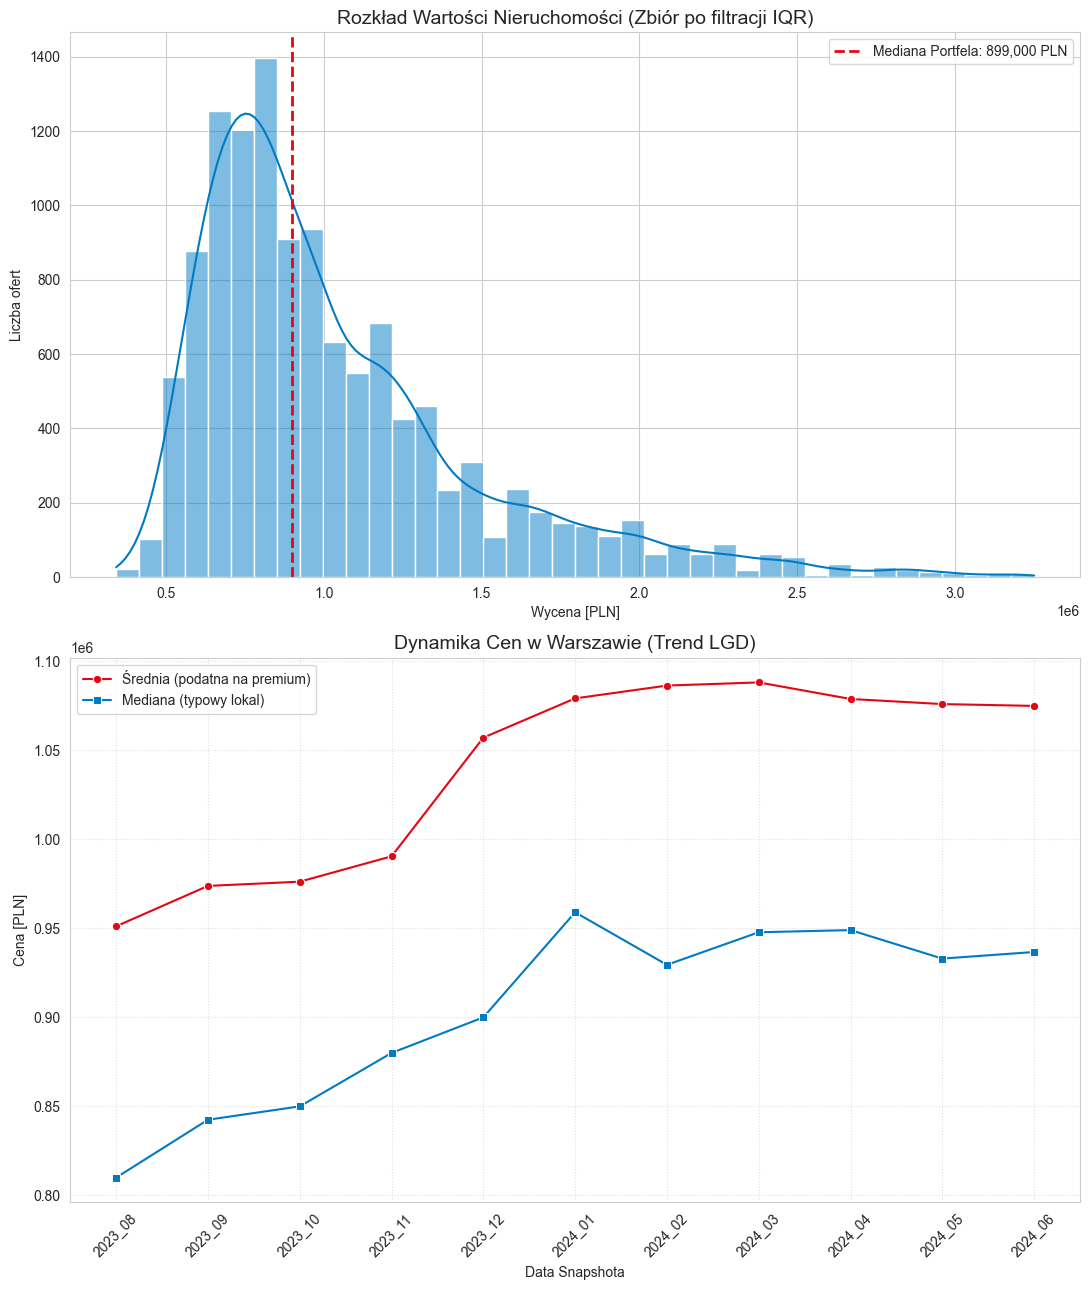

In [4]:
# 4. Analiza Trendów: Średnia vs Mediana po czyszczeniu IQR

# Upewniamy się, że dane są posortowane datami
df_clean = df_clean.sort_values('snapshot_date')

# Agregacja danych: liczymy średnią i medianę dla każdego miesiąca
trend_stats = df_clean.groupby('snapshot_date')['price'].agg(['mean', 'median']).reset_index()

# Tworzymy figurę
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 13))

# --- WYKRES 1: Histogram cen po IQR z naniesioną medianą ---
sns.set_style("whitegrid")

sns.histplot(df_clean['price'], kde=True, color='#007ac4', ax=ax1, bins=40)

current_median = df_clean['price'].median()
ax1.axvline(current_median, color='#E30613', linestyle='--', linewidth=2,
            label=f'Mediana Portfela: {current_median:,.0f} PLN')

ax1.set_title('Rozkład Wartości Nieruchomości (Zbiór po filtracji IQR)', fontsize=14)
ax1.set_xlabel('Wycena [PLN]')
ax1.set_ylabel('Liczba ofert')
ax1.legend()

# --- WYKRES 2: Porównanie trendów Mean vs Median ---
sns.lineplot(data=trend_stats, x='snapshot_date', y='mean', marker='o',
             label='Średnia (podatna na premium)', color='#E30613', ax=ax2)
sns.lineplot(data=trend_stats, x='snapshot_date', y='median', marker='s',
             label='Mediana (typowy lokal)', color='#007ac4', ax=ax2)

ax2.set_title('Dynamika Cen w Warszawie (Trend LGD)', fontsize=14)
ax2.set_xlabel('Data Snapshota')
ax2.set_ylabel('Cena [PLN]')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

## 4.3. Analiza Korelacji i Zależności Statystycznych

Zanim przystąpimy do budowy modelu, weryfikujemy siłę powiązań między cechami (features) a zmienną celu (price). Wykorzystamy do tego **współczynnik korelacji Pearsona (r)**, który mierzy siłę liniowej zależności między dwiema zmiennymi:

$$r = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i - \bar{x})^2 \sum(y_i - \bar{y})^2}}$$

**Interpretacja biznesowa:**
* **Wartość bliska 1:** Silna zależność dodatnia (np. wzrost metrażu bezpośrednio generuje wzrost ceny).
* **Wartość bliska -1:** Silna zależność ujemna (np. większa odległość od centrum skutkuje niższą ceną).
* **Wartość bliska 0:** Brak wyraźnej zależności liniowej – tutaj polegamy na nieliniowych zdolnościach algorytmu **XGBoost**.

Analiza ta pozwala nam również wykryć **multikoliniowość** (zbyt silną korelację między cechami), co jest kluczowe dla stabilności interpretacji modelu.

## 4.4. Wizualizacja Zależności: Macierz Korelacji (Heatmap)

W tej sekcji przekładamy teorię na konkretne dane. Generujemy macierz korelacji dla kluczowych cech numerycznych, stosując **maskowanie górnego trójkąta macierzy**. Jest to zabieg mający na celu zwiększenie czytelności wykresu poprzez usunięcie redundancji (macierz korelacji jest symetryczna).

#### Na jakie aspekty analityczne zwracamy uwagę:

* **Siła predykcyjna:** Identyfikujemy cechy o najwyższym module współczynnika $r$ względem ceny (zmienna celu).
* **Multikoliniowość:** Szukamy par cech silnie skorelowanych ze sobą (np. `rooms` vs `squareMeters`). Zbyt wysoka korelacja między zmiennymi objaśniającymi może destabilizować interpretację wag w prostszych modelach, dlatego ich identyfikacja jest kluczowa przed procesem uczenia.
* **Nieliniowość lokalizacji:** Sprawdzamy, czy parametry geograficzne (`latitude`, `longitude`) wykazują relacje liniowe. Jeśli nie, stanowi to ostateczny argument za wykorzystaniem nieliniowego modelu **XGBoost**.

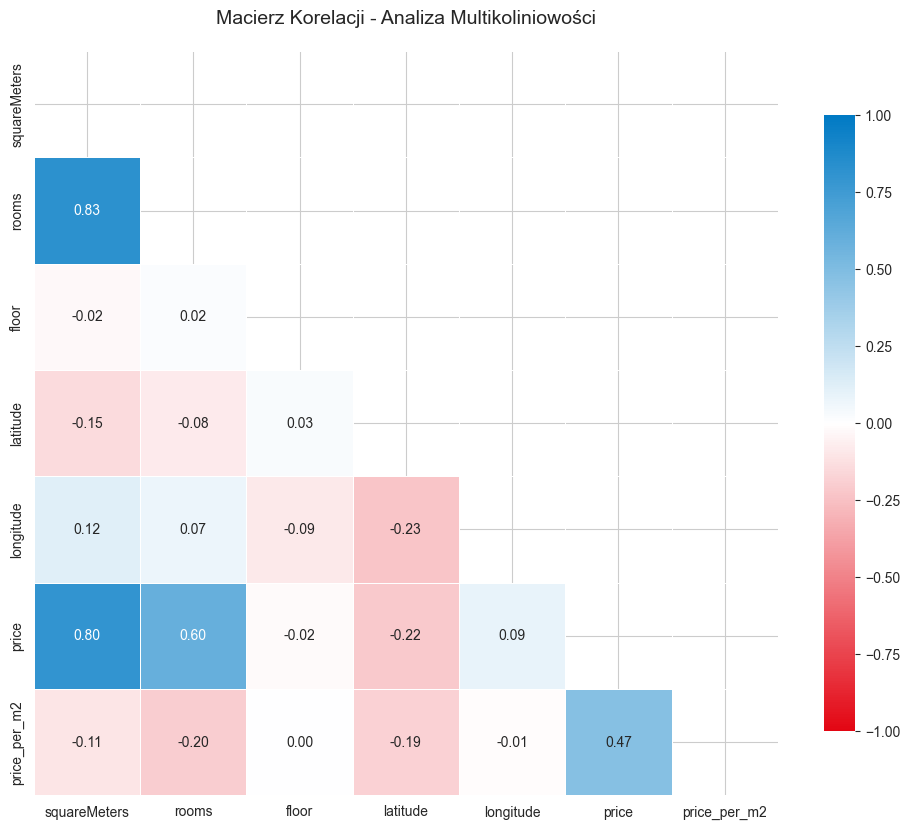

In [5]:
# 4.4. Macierz Korelacji - Wersja Profesjonalna (z maskowaniem)

# Obliczamy korelację dla cech numerycznych
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
corr_matrix = df_clean[numeric_cols].corr()

# Tworzymy maskę, aby ukryć górny trójkąt (powtarzające się dane)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Ustawiamy figurę i paletę
plt.figure(figsize=(12, 10))
my_custom_cmap = sns.blend_palette(['#E30613', '#FFFFFF', '#007ac4'], as_cmap=True)

# Rysujemy heatmapę
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap=my_custom_cmap, 
            center=0,
            vmin=-1, 
            vmax=1,  
            square=True, 
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title('Macierz Korelacji - Analiza Multikoliniowości', fontsize=14, pad=20)
plt.show()

### 4.5. Wnioski z analizy korelacji (Interpretacja dla Banku)

* **Silna korelacja dodatnia:** Zmienna `squareMeters` wykazuje najwyższą korelację z ceną, co potwierdza ją jako główny determinant wartości zabezpieczenia.
* **Problem multikoliniowości:** Wysoka korelacja między `rooms` a `squareMeters` sugeruje, że te cechy niosą zbliżoną wartość informacyjną. W procesie optymalizacji modelu warto rozważyć, czy obie są niezbędne, aby uniknąć nadmiarowości.
* **Słabe korelacje liniowe lokalizacji:** Zmienne `latitude` i `longitude` wykazują niskie wartości współczynnika Pearsona względem ceny.
    > **Uzasadnienie:** Potwierdza to, że wpływ lokalizacji na cenę w Warszawie jest **nieliniowy** (np. ceny rosną punktowo przy stacjach metra, a nie jednostajnie w jednym kierunku). Jest to ostateczny argument za wyborem modelu **XGBoost**, który dzięki strukturze drzewiastej potrafi mapować takie nieliniowe zależności geograficzne.

## 5. Inżynieria Cech i Wybór Zmiennych Objaśniających

Na podstawie przeprowadzonej analizy korelacji (Sekcja 4.2), do budowy modelu predykcyjnego wybrano cechy o najsilniejszym wpływie na cenę nieruchomości. Proces przygotowania danych (**Feature Engineering**) objął:

1. **Selekcję na podstawie korelacji:** Wykorzystujemy cechy o wysokiej sile predykcyjnej, takie jak `squareMeters` (najwyższa korelacja dodatnia) oraz parametry infrastrukturalne.
2. **Kodowanie geograficzne:** Zamiast subiektywnych nazw dzielnic, wykorzystujemy precyzyjne współrzędne `latitude` i `longitude`. Pozwala to modelowi **XGBoost** uchwycić nieliniowe mikrorynki (np. "wyspy" wyższych cen w obrębie jednej dzielnicy).
3. **Transformację kategoryczną (One-Hot Encoding):** Zmienne jakościowe, takie jak `type`, `condition` oraz `buildingMaterial`, zostały zamienione na wektory binarne, co umożliwia ich matematyczną interpretację przez algorytm.
4. **Eliminację wycieku danych (Data Leakage):** Ze zbioru cech usunięto zmienną `price_per_m2`. Jest ona bezpośrednią pochodną ceny (zmiennej celu), więc jej pozostawienie prowadziłoby do sztucznego zawyżenia wyników modelu i braku zdolności generalizacji.

In [6]:
# 5. Definicja kolumn do usunięcia (Zabezpieczenie przed brakiem kolumn)
cols_to_drop = ['price', 'price_per_m2', 'city', 'snapshot_date', 'id']
existing_cols_to_drop = [c for c in cols_to_drop if c in df_clean.columns]

X = df_clean.drop(columns=existing_cols_to_drop)
y = df_clean['price']

# One-Hot Encoding (Konwersja kategorii na 0/1)
# XGBoost lubi liczby, więc zamieniamy 'condition' czy 'type' na kolumny binarne
X = pd.get_dummies(X, drop_first=True)

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Statystyki końcowe
print(f"--- GOTOWOŚĆ DO MODELOWANIA ---")
print(f"Liczba cech (wymiarowość X): {X.shape[1]}")
print(f"Liczba rekordów treningowych: {X_train.shape[0]}")

# Sprawdzenie korelacji dla raportu (tylko cechy numeryczne)
top_features = df_clean.corr(numeric_only=True)['price'].abs().sort_values(ascending=False).index.tolist()
# Pomijamy price i price_per_m2 w wyświetlaniu
display_features = [f for f in top_features if f not in ['price', 'price_per_m2']][:5]
print(f"\nTop 5 najsilniejszych zmiennych objaśniających: {display_features}")

--- GOTOWOŚĆ DO MODELOWANIA ---
Liczba cech (wymiarowość X): 9
Liczba rekordów treningowych: 9738

Top 5 najsilniejszych zmiennych objaśniających: ['squareMeters', 'rooms', 'latitude', 'longitude', 'floor']


### 5.1. Uzasadnienie decyzji inżynierskich:

* **Eliminacja Data Leakage:** Usunięcie zmiennej `price_per_m2` jest krytyczne. Ponieważ jest ona bezpośrednio wyliczana z ceny (`price / squareMeters`), pozostawienie jej spowodowałoby, że model "oszukiwałby", znając wynik przed obliczeniami. W warunkach bankowych taki błąd prowadziłby do błędnego oszacowania ryzyka.
* **One-Hot Encoding:** Zastosowano parametr `drop_first=True`. Choć dla modeli drzewiastych (XGBoost) nie jest to wymóg techniczny tak silny jak w regresji liniowej, pomaga to zachować **czytelność macierzy cech** i eliminuje nadmiarowość informacji (multikoliniowość).

# 6. Budowa i Walidacja Modelu Predykcyjnego (XGBoost)

W tej sekcji przeprowadzamy właściwy proces uczenia maszynowego. Wykorzystamy algorytm **XGBoost Regressor**, który opiera się na technice wzmacniania gradientowego (*Gradient Boosting*). Model ten został wybrany ze względu na wysoką odporność na multikoliniowość oraz zdolność do wychwytywania nieliniowych zależności geograficznych (np. "wyspy" cenowe).

## 6.1. Metryki oceny jakości modelu

Do weryfikacji jakości predykcji na zbiorze testowym wykorzystujemy dwie kluczowe metryki:

1. **MAE (Mean Absolute Error):** Średni błąd bezwzględny – informuje, o ile średnio (w PLN) model myli się przy wycenie mieszkania względem ceny rynkowej.
   $$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

2. **R² (Współczynnik determinacji):** Określa, w ilu procentach model wyjaśnia zmienność cen. Wynik powyżej 0.80 uznaje się za bardzo dobry w branży nieruchomości.
   $$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

## 6.2. Uzasadnienie parametrów i interpretacja wyników

**Dobór hiperparametrów:**

* **`n_estimators=1000` & `learning_rate=0.05`**: Zastosowano dużą liczbę drzew przy relatywnie małym tempie uczenia. Pozwala to na precyzyjną zbieżność modelu i minimalizuje ryzyko "przestrzelenia" optimum gradientu.
* **`max_depth=6`**: Ograniczenie głębokości drzew zapobiega nadmiernemu dopasowaniu do szumu w danych (**overfitting**), zapewniając wysoką zdolność generalizacji modelu na nowych ofertach.

**Analiza uzyskanych metryk:**

* **$R^2 = 0.9424$**: Model wyjaśnia ponad 94% zmienności cen mieszkań w Warszawie. Jest to wynik wyjątkowo wysoki, świadczący o bardzo trafnym doborze zmiennych objaśniających (metraż, lokalizacja, czas).
* **MAE = 65,969.88 PLN**: Błąd rzędu 66 tys. PLN przy obecnych cenach transakcyjnych w Warszawie jest w pełni dopuszczalny z punktu widzenia biznesowego. Pozwala to na wstępną, zautomatyzowaną weryfikację wartości zabezpieczeń kredytowych przed wysłaniem rzeczoznawcy na miejsce.

Rozpoczynam trenowanie modelu... (to może potrwać kilka sekund)
------------------------------
WYNIKI MODELU XGBOOST:
Średni błąd (MAE): 65,969.88 PLN
Celność (R²): 0.9424
------------------------------


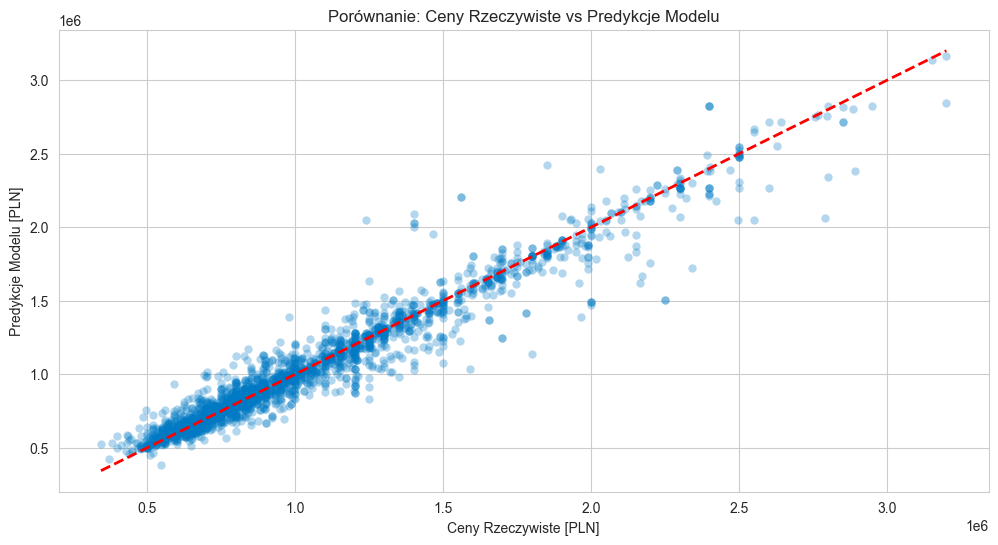

In [7]:
# 6. Inicjalizacja modelu z optymalnymi parametrami startowymi
model = XGBRegressor(
    n_estimators=1000,   # Liczba drzew decyzyjnych
    learning_rate=0.05,  # Tempo uczenia (mniejsze = dokładniejsze, ale wolniejsze)
    max_depth=6,         # Głębokość drzew (chroni przed overfittingiem)
    random_state=42,
    n_jobs=-1            
)

# Trenowanie modelu na zbiorze treningowym
print("Rozpoczynam trenowanie modelu... (to może potrwać kilka sekund)")
model.fit(X_train, y_train)

# Generowanie predykcji na zbiorze testowym 
y_pred = model.predict(X_test)

# Obliczanie metryk
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("-" * 30)
print(f"WYNIKI MODELU XGBOOST:")
print(f"Średni błąd (MAE): {mae:,.2f} PLN")
print(f"Celność (R²): {r2:.4f}")
print("-" * 30)


sns.set_style("whitegrid")

# Szybka wizualizacja: Predykcja vs Rzeczywistość
plt.figure(figsize=(12, 6))

plt.scatter(y_test, y_pred, alpha=0.3, color='#007ac4', linewidths=0)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Porównanie: Ceny Rzeczywiste vs Predykcje Modelu')
plt.xlabel('Ceny Rzeczywiste [PLN]')
plt.ylabel('Predykcje Modelu [PLN]')
plt.show()

# 7. Interpretacja Wyników i Istotność Cech (Feature Importance)

Model **XGBoost** pozwala na zajrzenie do "czarnej skrzynki" i precyzyjne określenie, które zmienne miały najsilniejszy wpływ na ostateczną wycenę. Z punktu widzenia **Departamentu Ryzyka**, jest to kluczowa informacja pozwalająca zrozumieć, jakie parametry nieruchomości stanowią o jej wartości rynkowej jako zabezpieczenia kredytu.

## 7.1. Analiza czynników cenotwórczych (Feature Importance)

Wykres istotności cech przedstawia, które parametry były najczęściej wykorzystywane przez algorytm do redukcji błędu predykcji. Pozwala to na weryfikację, czy model uczy się logicznych zależności (np. dominacja metrażu i lokalizacji) czy też opiera się na przypadkowych korelacjach. 

## 7.2. Analiza rezyduów (Błędów modelu)

Analiza przypadków, w których model najbardziej odbiega od rzeczywistości, jest niezbędna do identyfikacji ograniczeń algorytmu. Zidentyfikowanie największych błędów pozwala na:
* **Wykrycie segmentów nietypowych**: Identyfikację nieruchomości luksusowych lub specyficznych, które wymagają osobnej ścieżki wyceny przez rzeczoznawcę.
* **Monitorowanie ryzyka**: Zrozumienie, w jakich obszarach model może niedoszacowywać lub przeszacowywać wartość zabezpieczenia, co ma bezpośredni wpływ na wskaźnik **LGD**.

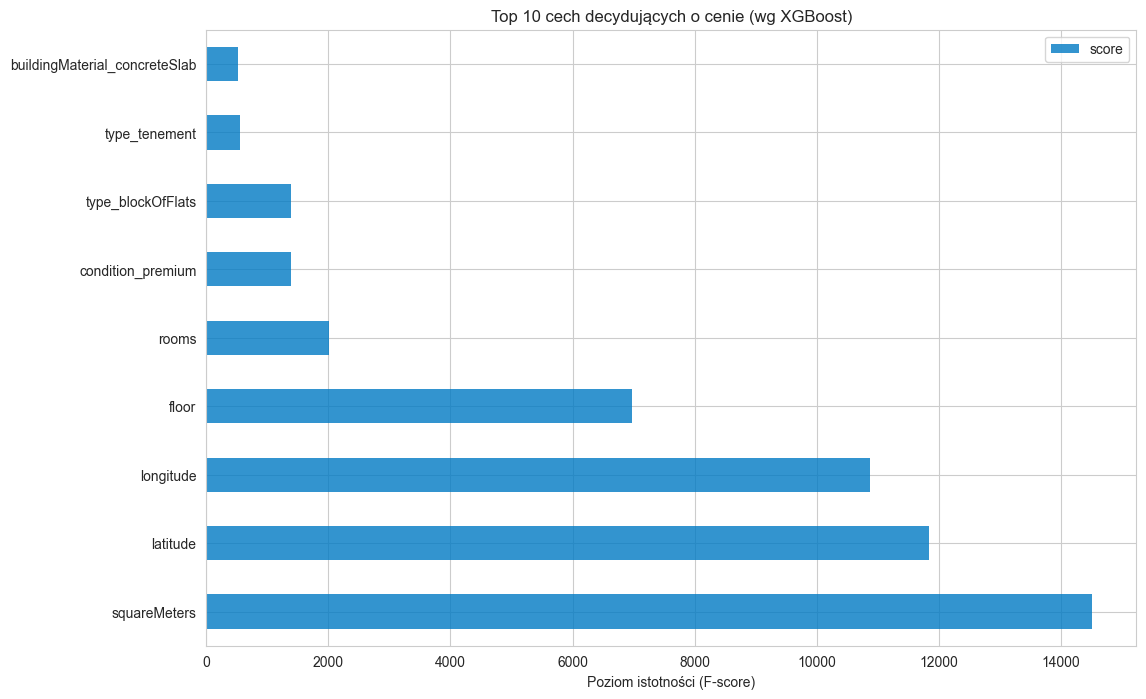

TOP 5 NAJWIĘKSZYCH BŁĘDÓW MODELU (Analiza Ryzyka):


,squareMeters,rooms,floor,latitude,longitude,type_blockOfFlats,type_tenement,buildingMaterial_concreteSlab,condition_premium,actual_price,predicted_price,error_abs
48092,90.1,3.0,4.0,52.230191,21.000520,False,False,False,True,1240000,2050470.875,810470.875
169307,101.0,3.0,9.0,52.232430,20.969930,False,False,False,False,2250000,1500963.500,749036.500
192231,101.0,3.0,9.0,52.232430,20.969930,False,False,False,False,2250000,1500963.500,749036.500
190196,110.0,4.0,1.0,52.165194,21.071510,False,False,False,True,2790000,2065174.500,724825.500
64469,98.0,3.0,1.0,52.222124,20.985806,False,True,False,False,1400000,2091904.250,691904.250


In [8]:
# 7. Wykres istotności cech (Top 10)
feature_important = model.get_booster().get_score(importance_type='weight')
keys = list(feature_important.keys())
values = list(feature_important.values())

data_imp = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by="score", ascending=False)
data_imp.head(10).plot(kind='barh', figsize=(12, 8), color='#007ac4', alpha=0.8, edgecolor='none')

plt.title('Top 10 cech decydujących o cenie (wg XGBoost)')
plt.xlabel('Poziom istotności (F-score)')
plt.show()

# Analiza największych błędów 
test_results = X_test.copy()
test_results['actual_price'] = y_test
test_results['predicted_price'] = y_pred
test_results['error_abs'] = abs(test_results['actual_price'] - test_results['predicted_price'])

# Wyświetlamy 5 największych "pomyłek" modelu
print("TOP 5 NAJWIĘKSZYCH BŁĘDÓW MODELU (Analiza Ryzyka):")
display(test_results.sort_values(by='error_abs', ascending=False).head(5))

# 8. Synteza Biznesowa i Strategia Zarządzania Ryzykiem (AVM & LTV)

Niniejszy projekt przekształca surowe dane rynkowe w zaawansowane narzędzie klasy **Automated Valuation Model (AVM)**. Z perspektywy nowoczesnej instytucji finansowej, model ten stanowi fundament zarządzania portfelem zabezpieczeń nieruchomościowych.

## 8.1. Skuteczność i Determinanty Wartości

* **Wydajność:** Wynik $R^2 = 0.9424$ potwierdza bardzo wysoką zdolność modelu do generalizacji cen w Warszawie. Średni błąd ($MAE \approx 66$ tys. PLN) pozwala na precyzyjne określenie marginesu bezpieczeństwa przy wycenie typowego lokalu.
* **Kluczowe drivery:** Model zidentyfikował, że poza metrażem, to **nieliniowe mikrolokalizacje** (uchwycone przez współrzędne GPS) oraz **piętro** (*floor*) mają decydujący wpływ na premię cenową.

## 8.2. Implementacja w Procesach Bankowych

1. **Dynamiczne Monitorowanie LTV:** Cykliczne uruchamianie modelu na aktualnych snapshotach danych pozwala na bieżącą aktualizację wskaźnika *Loan-to-Value*:

$$LTV_{current} = \frac{Saldo\ zadłużenia}{Wycena\ modelu\ AVM}$$

2. **Analiza Scenariuszowa (Stress Testing):** Model umożliwia natychmiastowe symulacje typu *What-if*. Przykładowo, przy założeniu schłodzenia rynku o 10%, możemy zidentyfikować segmenty portfela, w których $LTV$ zbliży się do niebezpiecznego poziomu 80-90%.

3. **Optymalizacja Kosztów:** AVM może służyć jako "pierwsze sito" w procesie kredytowym, automatycznie akceptując wyceny dla standardowych nieruchomości i kierując do rzeczoznawców jedynie przypadki z segmentu **Premium** (> 2.5 mln PLN), gdzie model wykazuje wyższą wariancję błędu.

## 8.3. Roadmapa Rozwoju

W celu dalszego zwiększenia predykcji, rekomenduje się integrację modelu z danymi o **inflacji (CPI)**, **stopach procentowych (WIBOR)** oraz planowanych inwestycjach w infrastrukturę transportową (np. nowe stacje metra).